![logo](figures/LogoLine_horizon_C3S.png)

# Urban Heat Island analysis for Paris using C3S Atlas/CORDEX data

This Jupyter Notebook reproduces the **Urban Climate product** from the C3S Atlas. This product is only available for high-resolution datasets that incorporate some form of urban representation (bulk or urban canopy model), including **CORDEX-CORE**, **CORDEX-EUR-11**, and **CERRA**. The notebook illustrates the **Urban Heat Island (UHI) intensity**, or **urban–rural contrast**, calculated by subtracting rural area temperatures from those of the urban area, based on the model-specific urban mask within each dataset.

- Urban and rural surrounding areas are delineated using the static urban fraction variables available in [Langendijk, G. S. et al. (2026)](https://doi.org/10.5281/zenodo.15691322).
- The methodology and python package ([URCLIMASK](https://github.com/FPS-URB-RCC/urclimask)) to delineate urban and rural areas is described in [Diez-Sierra, J. et al. (2025)](https://doi.org/10.1038/s41597-025-06257-1).
- The selection of cities available in the C3S Atlas is based on [Langendijk, G. S. et al. (2025)](https://doi.org/10.1038/s42949-025-00325-6).

**This script can be used to extend C3S Atlas products to additional cities and variables.**

The figure below shows the Annual cycle of the **urban–rural temperature difference (Urban Heat Island, UHI)** for mean temperature (°C) from CORDEX-EUR-11 under a 2 °C warming scenario. It can be visualized in the C3S Atlas using the following [Permalink](https://atlas.climate.copernicus.eu/atlas/58bOMS9e).

![t-CORDEX-EUR-11_city](figures/tn-CORDEX-EUR-11_city.png)

## Supporting Papers

### 1. Global Urban-Rural Dataset
**Diez-Sierra, J. et al. (2025)**. A global CORDEX-based dataset delineating urban areas and their surroundings to assess climate change on megacities. (Scientific Data). [https://doi.org/10.1038/s41597-025-06257-1](https://doi.org/10.1038/s41597-025-06257-1)

This work presents the first **global RCM-based database** of urban and rural areas. It uses model-specific urban fraction variables and static inputs from **CORDEX-CORE** (global) and **EURO-CORDEX** (Europe) simulations. Urban and surrounding rural areas are defined for a representative set of megacities at 25 km (global) and 12.5 km (Europe) resolutions.  
The paper provides a Python workflow for extending the analysis to additional cities and models, as well as tools for evaluating the **urban heat island (UHI)** effect.

### 2. Representation of Urban Areas in Regional Climate Models
**Langendijk, G. S. et al. (2025)**. Representation of global megacities and their urban heat island in CORDEX-CORE regional climate model simulations. (Urban Sustainability). [https://doi.org/10.1038/s42949-025-00325-6](https://doi.org/10.1038/s42949-025-00325-6). 

This study evaluates how **CORDEX-CORE** models represent urban areas and the **urban heat island effect** globally. Despite the coarse resolution (~25 km), the models capture the thermal imprint of large cities, with **RegCM** reproducing nighttime UHI more accurately than **REMO**.  
The study highlights limitations in urban land-surface representation and underestimation of impervious surfaces, providing guidance for improving urban parameterizations in regional climate modeling.  
Paris is one of the set of **selected cities** in Langendijk, G. S. et al. (2025). This selection was used for the [C3S Atlas](https://atlas.climate.copernicus.eu/atlas).

## Load Python packages and clone and install the c3s-atlas GitHub repository from the ecmwf-projects

Clone (`git clone`) the [c3s-atlas](https://github.com/ecmwf-projects/c3s-atlas) repository and install it (`pip install -e .`).

Further details on how to clone and install the repository are available in the [requirements section](https://github.com/ecmwf-projects/c3s-atlas?tab=readme-ov-file#requirements)

In [1]:
import xarray as xr
import glob
import os
from datetime import date
import numpy as np
from pathlib import Path
import cdsapi
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from c3s_atlas.utils import (
    season_get_name,
    extract_zip_and_delete,
)
from c3s_atlas.customized_regions import (
    Mask
)
from c3s_atlas.analysis import (
    monthly_weighted_average, 
)
from c3s_atlas.products import (
    annual_cycle,
)
from c3s_atlas.GWLs import (
    load_GWLs,
    select_member_GWLs,
    get_mean_data_by_months
)

[**URCLIMASK**](https://github.com/FPS-URB-RCC/urclimask) provides a reproducible and flexible workflow to delineate **urban** and **rural** masks from regional climate model simulations.  
It enables consistent analysis of **urban climate effects** and can be easily extended to additional cities and datasets.

In [2]:
from urclimask.urban_areas import (
    UrbanVicinity
)
from urclimask.utils import (
    kelvin2degC,
    traverseDir,
    fix_360_longitudes,
    RCM_DICT,
    load_ucdb_city
)

from urclimask.UHI_analysis import (
    UrbanIsland
)

### Download climate data with the CDS API

- Catalogue: [Gridded dataset underpinning the Copernicus Interactive Climate Atlas](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview)

> ⚠️ **Warning: Exposed API Credentials**
>
> For security reasons, it is not recommended to hardcode your Copernicus Climate Data Store (CDS) API credentials — such as `cdsapi_url` and `cdsapi_key` — directly in notebooks.
>
> Instead, it is best to store them securely in a `.cdsapirc` file located in your home directory.
>
> 📄 More info: [CDS API - How to use the API](https://cds.climate.copernicus.eu/how-to-api)

In [3]:
cdsapi_url= "https://cds.climate.copernicus.eu/api"
cdsapi_key= ""

In [ ]:
c = cdsapi.Client(url=cdsapi_url, key=cdsapi_key)

Running the code blocks below will download the data from the CDS as specified by the following API keywords:

**Variables:** `Orography; Land Area Fraction`  
**Domain:** `Europe`  
**Horizontal Resolution:** `12.5 km`  
**Temporal Resolution:** `Fixed`  
**Global Climate Model (GCM):** `CNRM-CERFACS-CM5`  
**Regional Climate Model (RCM):** `ICTP-RegCM4.6`  
**Ensemble Member:** `r1i1p1`  
**Experiment:** `Historical`

##### Download fixed variables (orography, land area fraction, and urban fraction) required to delineate urban and rural areas.

In [6]:
dest = Path('./data/CORDEX-EUR-11/') # directory to download the files
os.makedirs(dest, exist_ok=True)

In [ ]:
filename_orog = 'orog_EUR-11_CNRM-CERFACS-CNRM-CM5_historical_r1i1p1_ICTP-RegCM4-6_v2_fx'

dataset = "projections-cordex-domains-single-levels"
request = {
    "domain": "europe",
    "experiment": "historical",
    "horizontal_resolution": "0_11_degree_x_0_11_degree",
    "temporal_resolution": "fixed",
    "variable": ["orography"],
    "gcm_model": "cnrm_cerfacs_cm5",
    "rcm_model": "ictp_regcm4_6",
    "ensemble_member": "r1i1p1"
}
client = cdsapi.Client()
zip_path = dest / f"{filename_orog}.zip"
client.retrieve(dataset, request).download(zip_path)
extract_zip_and_delete(zip_path) 

In [ ]:
filename_sftlf = 'sftlf_EUR-11_CNRM-CERFACS-CNRM-CM5_historical_r1i1p1_ICTP-RegCM4-6_v2_fx'

dataset = "projections-cordex-domains-single-levels"
request = {
    "domain": "europe",
    "experiment": "historical",
    "horizontal_resolution": "0_11_degree_x_0_11_degree",
    "temporal_resolution": "fixed",
    "variable": [
        "land_area_fraction",
    ],
    "gcm_model": "cnrm_cerfacs_cm5",
    "rcm_model": "ictp_regcm4_6",
    "ensemble_member": "r1i1p1"
}

client = cdsapi.Client()
zip_path = dest / f"{filename_sftlf}.zip"
client.retrieve(dataset, request).download(zip_path)
extract_zip_and_delete(zip_path) 

The **urban fraction variable** used in this analysis was obtained from:  **Langendijk, G. S. et al. (2025)**. CORDEX-CORE urban and impervious surface area dataset (v1.0.0). Zenodo. [https://doi.org/10.5281/zenodo.15700267](https://doi.org/10.5281/zenodo.15700267). A example for ICTP-RegCM4.6 model is included in the [reference-grids](https://github.com/ecmwf-projects/c3s-atlas/tree/main/auxiliar/reference-grids) folder.

In [14]:
filename_sfturf = "sftimf_EUR-11_ICTP_RegCM4-6_v1_fx"

## Define urban and rural surrounding areas

The methodology proposed in this study relies on three static variables commonly available in most RCM outputs: urban fraction (sfturf or sftimf), orography (orog), and land area fraction (sftlf). The algorithm can be briefly described as follows. A minimum threshold for the UF determines the grid cells representing the city in the model. Potential rural surrounding areas are then determined based on three main criteria: (1) grid cells must have UF values below a specified threshold; (2) large water bodies (lakes, oceans, and rivers) are excluded via a minimum land area fraction threshold; and (3) grid cells with an elevation difference above a threshold with respect to the urban area are excluded to avoid the effect of altitude on temperature (i.e., adiabatic lapse rate). Grid cells complying with these criteria are selected as candidate rural surroundings areas. The final rural surrounding area is obtained from this candidate grid cells through an iterative morphological dilation process expanding outward from the urban cells. Iterations stop when the number of rural cells reaches a predefined ratio relative to the number of urban cells.

A full description of the methodology can be found at [Diez-Sierra, J. et al. (2025)](https://doi.org/10.1038/s41597-025-06257-1).

### Parameters
The parameters used to delineate urban areas and their rural surroundings are defined in [Diez-Sierra, J. et al. (2025)](https://doi.org/10.1038/s41597-025-06257-1).

The following table describes the hyperparameters implemented in the algorithm.

| Hyperparameter     | Description |
|--------------------|------------|
| `lon_city` and `lat_city` | Longitude and latitude of the city center. |
| `lon_lim` and `lat_lim` | Geographic boundaries of the study area (including city surroundings) relative to the city center (`lon_city` and `lat_city`). Grid cells outside these limits (`lon_city ± lon_lim` and `lat_city ± lat_lim`) are excluded from the analysis. |
| `urban_th` | Urban fraction threshold (%). Grid cells with urban fraction values above this threshold are classified as urban cells. |
| `urban_sur_th` | Urban surrounding threshold (%). Grid cells with urban fraction values below this threshold are candidates for rural surroundings. Defaults to `urban_th`. |
| `orog_diff` | Maximum elevation difference (in meters) relative to the range (max–min) of urban cell elevations (`urban min elev - orog_diff < rural elev < urban max elev + orog_diff`). Pixels exceeding this difference are excluded. |
| `sftlf_th` | Minimum land area fraction (%) required to include a grid cell in the analysis. |
| `min_city_size` | Minimum size (in number of edge-connected cells) for urban clusters to be retained. Urban clusters are excluded, except for the main cluster nearest to `lon_city` and `lat_city`, which is always retained. |
| `ratio_r2u` | Ratio of rural to urban grid cells. The iterative dilation process stops once this ratio is achieved. |


In [15]:
city = 'Paris'
lon_city = 2.35
lat_city = 48.85

domain = 'EUR-11'
model = 'RegCM'
scenario = "evaluation"

urban_var = 'sftimf'

urban_th = 40
urban_sur_th = 10
orog_diff = 100
sftlf_th = 70
ratio_r2u = 2
min_city_size = 10
lon_lim = 1
lat_lim = 1

project = "CORDEX"
scenario = "historical"
var = 'tasmin'

Infer domain resolution in degrees and create filename

In [16]:
domain_resolution = int(domain.split('-')[1])
base_filename = f'{city}-{domain}_ECMWF-ERA5_{scenario}_r1i1p1f1_{model}'

##### Download minimum temperature to compute UHI intensity

Running the code blocks below will download the data from the CDS as specified by the following API keywords:

**Variables:** `Minimum temperature`  
**Domain:** `Europe`  
**Horizontal Resolution:** `12.5 km`  
**Temporal Resolution:** `daily`  
**Global Climate Model (GCM):** `CNRM-CERFACS-CM5`  
**Regional Climate Model (RCM):** `ICTP-RegCM4.6`  
**Ensemble Member:** `r1i1p1`  
**Experiment:** `Historical`

In [ ]:
client = cdsapi.Client()

for start_year in range(1970, 2005, 2):
    end_year = start_year + 1
    filename = dest / f"{base_filename}_{start_year}-{end_year}.zip"
    
    request = {
        "domain": "europe",
        "experiment": "historical",
        "horizontal_resolution": "0_11_degree_x_0_11_degree",
        "temporal_resolution": "daily_mean",
        "variable": ["minimum_2m_temperature_in_the_last_24_hours"],
        "gcm_model": "cnrm_cerfacs_cm5",
        "rcm_model": "ictp_regcm4_6",
        "ensemble_member": "r1i1p1",
        "start_year": [str(start_year), str(end_year)],
        "end_year": [str(start_year), str(end_year)],
    }
    
    print(f"Downloading {start_year}-{end_year}...")
    client.retrieve(dataset, request).download(str(filename))
    
    # Extraer y borrar ZIP
    extract_zip_and_delete(filename)

### Load static variables

Load static variables, such as urban fraction (sfturf), terrain elevation (orography) or land-sea fraction (sftlf).

In [18]:
sfturf_path = f"../../auxiliar/reference-grids/{filename_sfturf}.nc"
orog_path   = dest / f"{filename_orog}.nc"
sftlf_path  = dest / f"{filename_sftlf}.nc"

ds_sfturf = xr.open_dataset(sfturf_path)
ds_orog   = xr.open_dataset(orog_path)
ds_sftlf  = xr.open_dataset(sftlf_path)

ds_sfturf = fix_360_longitudes(ds_sfturf)
ds_orog   = fix_360_longitudes(ds_orog)
ds_sftlf  = fix_360_longitudes(ds_sftlf)

Add parameters to the function

In [19]:
URBAN = UrbanVicinity(
    urban_sur_th = urban_sur_th,
    orog_diff = orog_diff,
    sftlf_th = sftlf_th,
    ratio_r2u = ratio_r2u,
    min_city_size = min_city_size,
    lon_city = lon_city,
    lat_city = lat_city,
    lon_lim = lon_lim,
    lat_lim = lat_lim,
    model = model,
    domain = domain,
    urban_th = urban_th,
    urban_var = urban_var
)

Crop area around the city

In [20]:
ds_sfturf = URBAN.crop_area_city(ds = ds_sfturf, res = domain_resolution)
ds_orog = URBAN.crop_area_city(ds = ds_orog, res = domain_resolution)
ds_sftlf = URBAN.crop_area_city(ds = ds_sftlf, res = domain_resolution)

### Define the urban mask

In [ ]:
sfturf_mask, sfturf_sur_mask, orog_mask, sftlf_mask = URBAN.define_masks(
    ds_sfturf = ds_sfturf, 
    ds_orog = ds_orog, 
    ds_sftlf = ds_sftlf,
)

### Define rural vicinity areas

In [22]:
urmask = URBAN.select_urban_vicinity(
    sfturf_mask = sfturf_mask, 
    orog_mask = orog_mask,
    sftlf_mask = sftlf_mask,
    sfturf_sur_mask = sfturf_sur_mask
)

#### Plot the static variables and the urban and rural vicinity mask

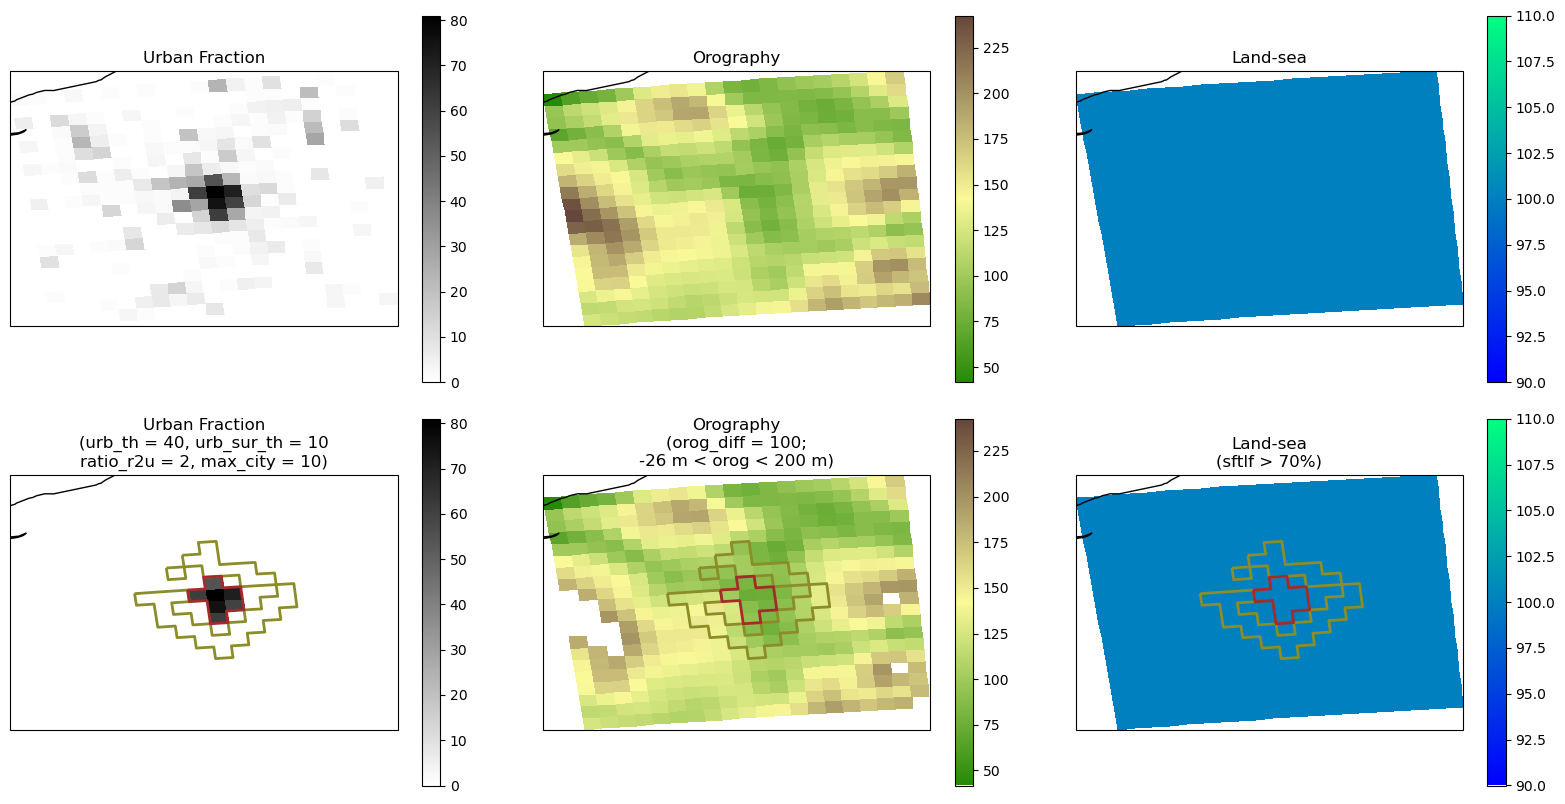

In [23]:
fig = URBAN.plot_static_variables(ds_sfturf = ds_sfturf, 
                                  ds_orog = ds_orog, 
                                  ds_sftlf = ds_sftlf,
                                  sfturf_mask = sfturf_mask, 
                                  orog_mask = orog_mask, 
                                  sftlf_mask = sftlf_mask,
                                  urban_areas = urmask,
                                 composite = False)

Urban and rural areas correspond to the red and green polygons, respectively. The land–sea mask represents the percentage of land (i.e., non-water surface) within each grid cell. Orography and the land–sea mask are used to exclude rural cells with large elevation differences or a high percentage of water relative to the urban cells, ensuring consistency, as these factors can affect climate variables when comparing urban and rural areas.

## Calculate Urban Heat Island (UHI)

#### Load climate variable

In [ ]:
nc_files = sorted(dest.glob(f"{base_filename}*.nc"))

ds_RCM = xr.open_mfdataset(
    nc_files,
    combine="by_coords",
    parallel=True
).sortby("time")

In [25]:
ds_RCM  = fix_360_longitudes(ds_RCM)
ds_RCM = kelvin2degC(ds_RCM, var)
ds_RCM = fix_360_longitudes(ds_RCM)
ds_RCM = URBAN.crop_area_city(ds = ds_RCM, res = domain_resolution)

In [26]:
UHI = UrbanIsland(
    ds = ds_RCM[var],
    urban_vicinity = urmask,
    anomaly = 'abs')

### Urban Heat Island Climatology Map

The `plot_UI_map` function computes the **monthly mean** of a given dataset.  
It first calculates the average temperature for the **rural cells** selected in previous steps, and then subtracts this mean from all cells to obtain the spatial **anomaly** or **urban-rural contrast**.

**Plot Interpretation**
- Urban–rural contrast of nocturnal (tasmin) temperature  
- **Red polygon areas**: Urban areas  
- **Green polygon areas**: Rural areas  

This visualization clearly highlights the Urban Heat Island intensity.

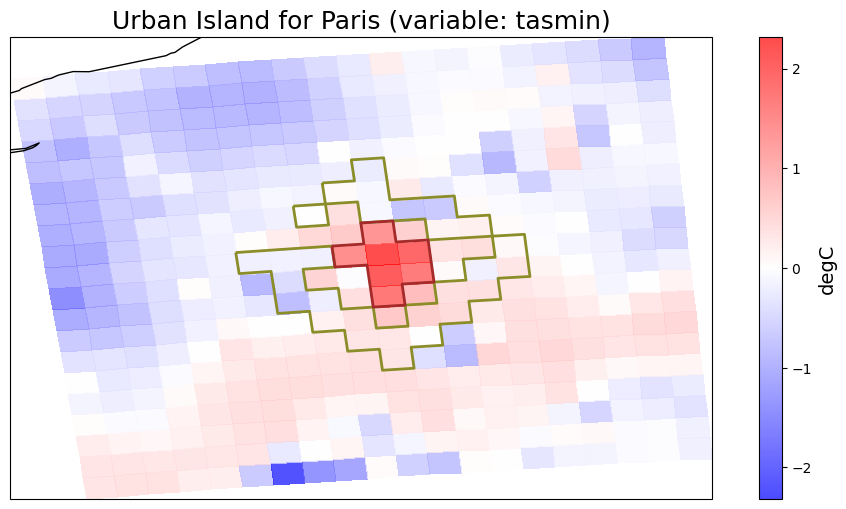

In [28]:
fig = UHI.plot_UI_map(
    city_name = city)

### Urban Heat Island Annual Cycle

The `plot_UI_annual_cycle` function computes the **monthly spatial mean** of a given dataset.  
It first calculates the average temperature for the **rural cells** selected in previous steps, and then subtracts this mean from all cells to obtain the **anomaly** or **urban-rural contrast**.

Plot Interpretation
- **Red lines**: Temperature anomaly in **urban areas** relative to the average of rural cells.  
- **Green lines**: Temperature anomaly in **rural areas** relative to the average of rural cells.  
- **Thicker and dashed lines**: Represent the **average anomaly** and the **percentiles** (10, 25, 75, and 90).

This visualization clearly highlights the differences in annual cycles between **urban** and **rural** regions.

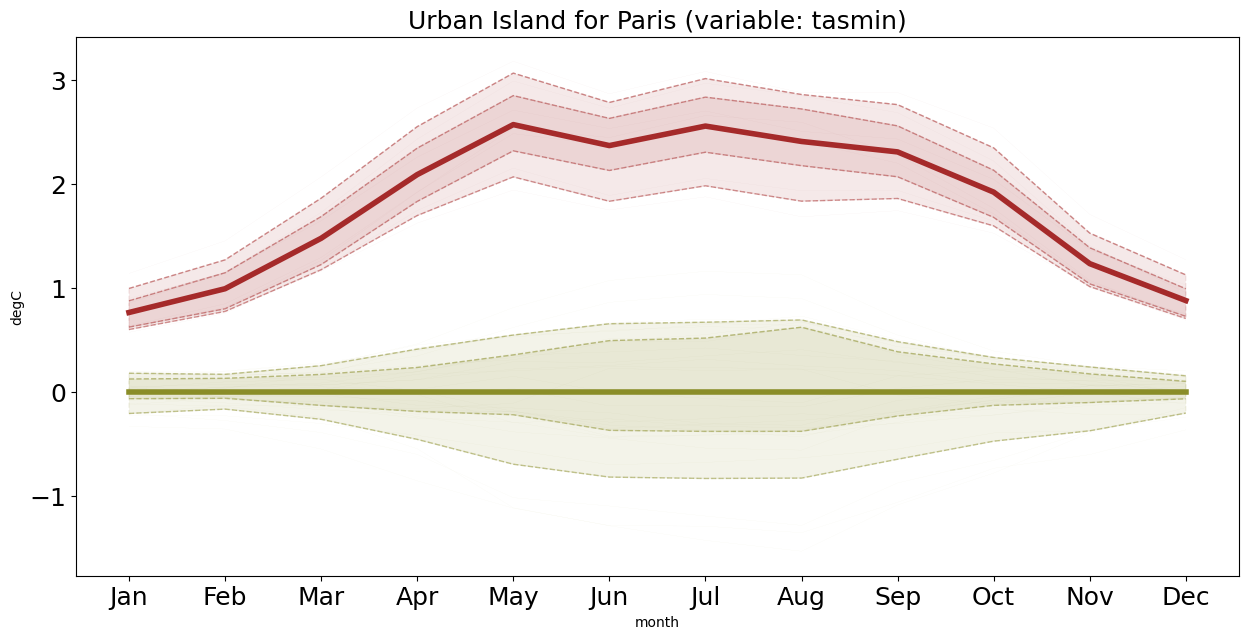

In [49]:
fig = UHI.plot_UI_annual_cycle(
    percentiles = [10, 25],
    gridcell_series = True, 
    city_name = city)

In contrast to the results presented in the first figure of the script, which depict the full model ensemble, this figure shows results for a single model, illustrating the spatial variability of the Urban Heat Island effect as a function of the specific grid cell analyzed.